# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
     OrdinalEncoder,
     OneHotEncoder,
     LabelEncoder,
     StandardScaler,
     MinMaxScaler,
     RobustScaler,
     
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
     accuracy_score,
     precision_score,
     recall_score,
     f1_score,
     
     classification_report
)

import joblib

# Load Dataset

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv")

# Data Exploration Functions

In [3]:
train.head(5)      # Preview of first 5 rows, if found tranked columns apply pd.set_option('display.max_columns', None) then train.head(5)



,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [4]:
train.tail(5)    # Preview of first 5 rows

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [5]:
train.sample(5)        # preview of random 5 rows

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
179796,179796,at-risk,7.69,91.4,26.03,2086.0,9153.0,38.4,3.55,non-veg,medium,poor,active,yes,female
435436,435436,at-risk,NaN,84.3,23.47,2227.0,6792.0,48.0,1.98,non-veg,NaN,good,moderate,occasional,female
450874,450874,at-risk,5.83,65.6,21.84,2468.0,5576.0,37.5,2.27,non-veg,medium,poor,moderate,no,other
366399,366399,fit,6.37,75.8,22.09,2061.0,6954.0,32.7,0.93,non-veg,high,average,moderate,no,male
589255,589255,at-risk,6.95,73.8,23.44,2339.0,NaN,0.0,1.76,balanced,high,NaN,sedentary,no,NaN


In [6]:
train.shape

(690088, 15)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [8]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [9]:
train.duplicated().sum()           #if found duplicated values apply train.drop_duplicates(inplace=True) code to remove duplicated

np.int64(0)

In [10]:
train.nunique()

id                         690088
health_condition                3
sleep_duration                701
heart_rate                    537
bmi                          1596
calorie_expenditure          2101
step_count                  12807
exercise_duration             856
water_intake                  400
diet_type                       3
stress_level                    3
sleep_quality                   3
physical_activity_level         3
smoking_alcohol                 3
gender                          3
dtype: int64

In [11]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [12]:
train.corr(numeric_only = True)

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
id,1.000000,-0.001340,-0.001008,-0.000095,-0.000917,0.000155,-0.000883,0.001147
sleep_duration,-0.001340,1.000000,-0.005183,-0.074576,-0.004075,0.004082,0.001708,0.000519
heart_rate,-0.001008,-0.005183,1.000000,0.000612,-0.003967,-0.005486,-0.005679,0.000192
bmi,-0.000095,-0.074576,0.000612,1.000000,0.117624,-0.020548,-0.020289,0.000638
calorie_expenditure,-0.000917,-0.004075,-0.003967,0.117624,1.000000,0.400102,0.393592,0.001534
step_count,0.000155,0.004082,-0.005486,-0.020548,0.400102,1.000000,0.438236,-0.000588
exercise_duration,-0.000883,0.001708,-0.005679,-0.020289,0.393592,0.438236,1.000000,0.002199
water_intake,0.001147,0.000519,0.000192,0.000638,0.001534,-0.000588,0.002199,1.000000


# Data Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

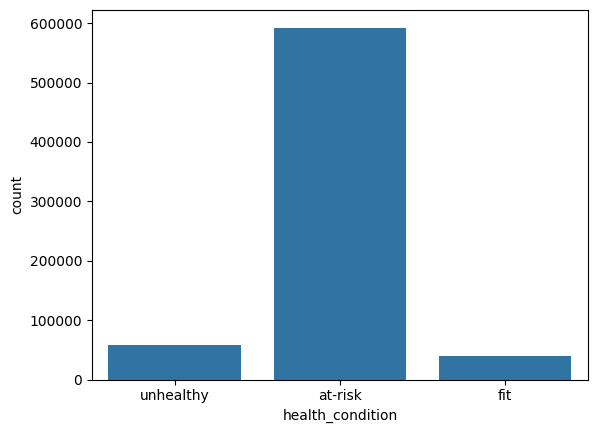

In [13]:
#health_condition distribution

sns.countplot(
    data = train,
    x = "health_condition"
)
plt.show

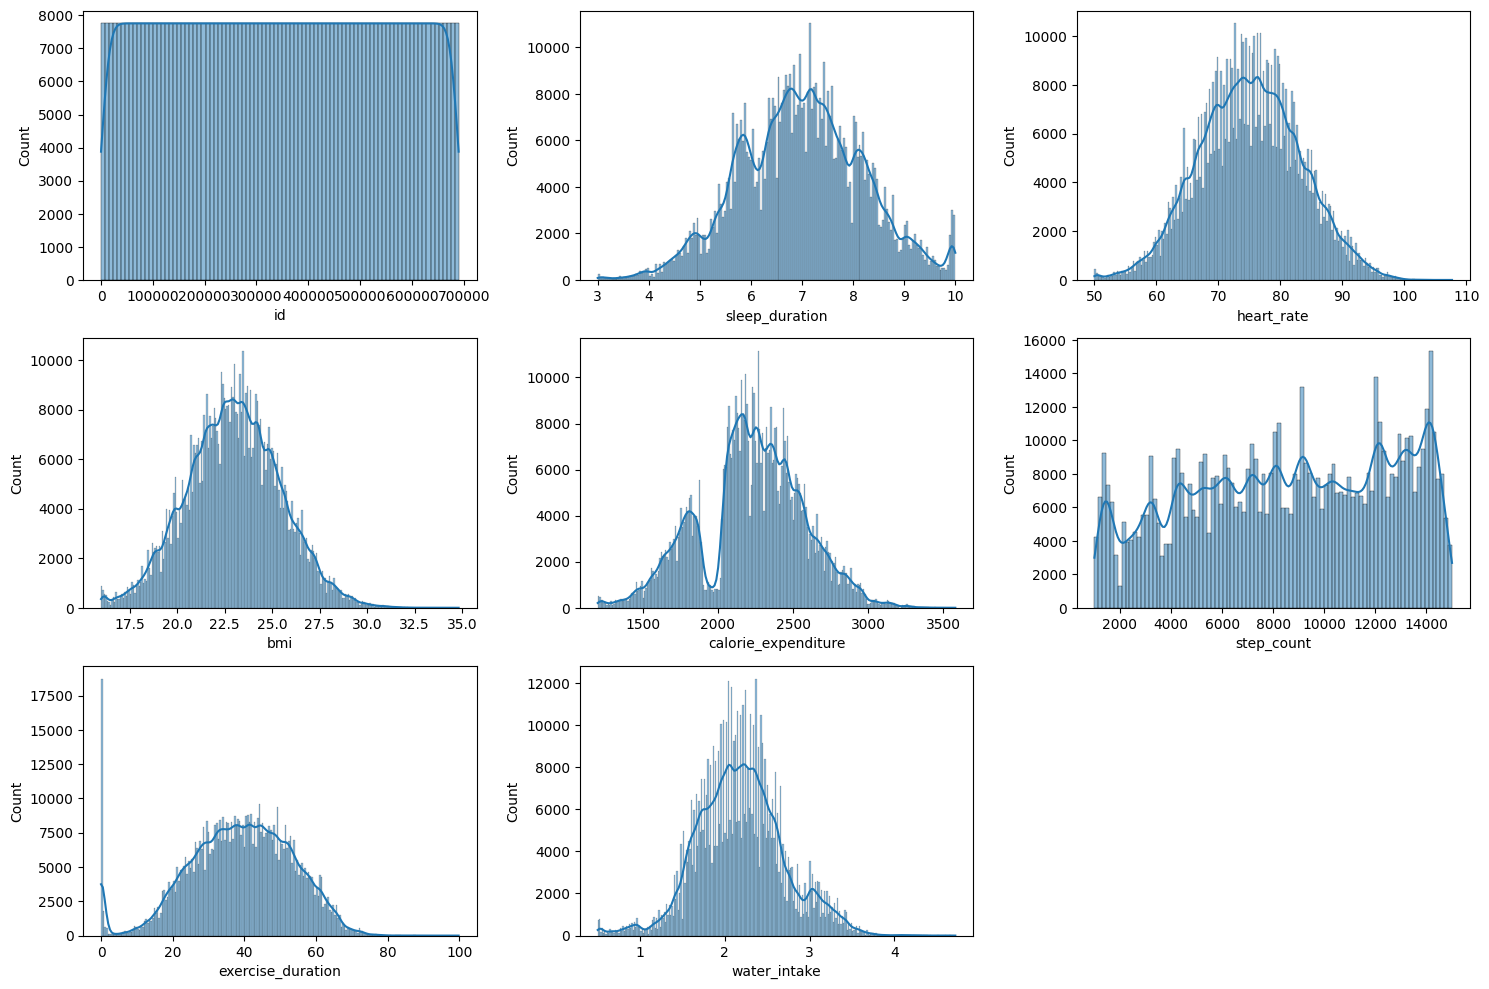

In [14]:
#histplot distribution among numerical 

num_cols = train.select_dtypes(include  = ['int64','float']).columns
plt.figure(figsize = (15,10))

for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(train[col],kde = True)
    
plt.tight_layout()
plt.show()    

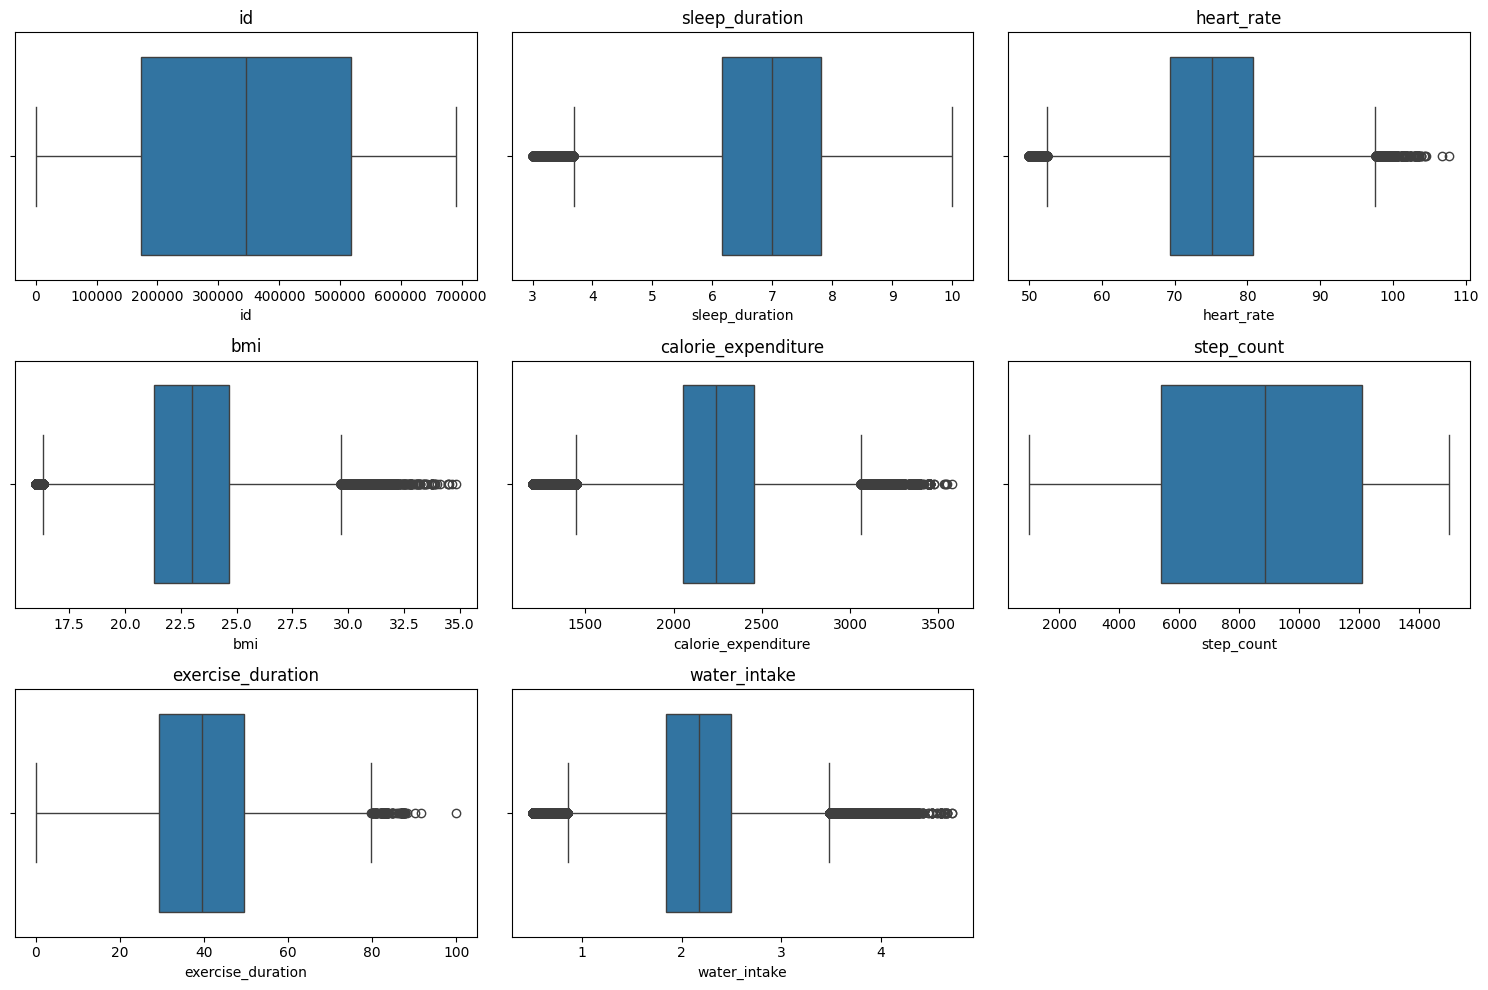

In [15]:
#boxplot distribution among numerical 

num_cols = train.select_dtypes(include="number").columns
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
#Checking skewness in numerical data

num_cols = train.select_dtypes(include = ["int64","float64"]).columns
skew_train = pd.DataFrame({
        "Columns" : num_cols,
        "skewness" : [train[col].skew() for col in num_cols]
    })
print(skew_train)

               Columns      skewness
0                   id  1.243298e-15
1       sleep_duration -8.232339e-03
2           heart_rate  4.382013e-04
3                  bmi  2.463976e-02
4  calorie_expenditure -1.839400e-01
5           step_count -1.802384e-01
6    exercise_duration -3.746098e-01
7         water_intake  1.099603e-01


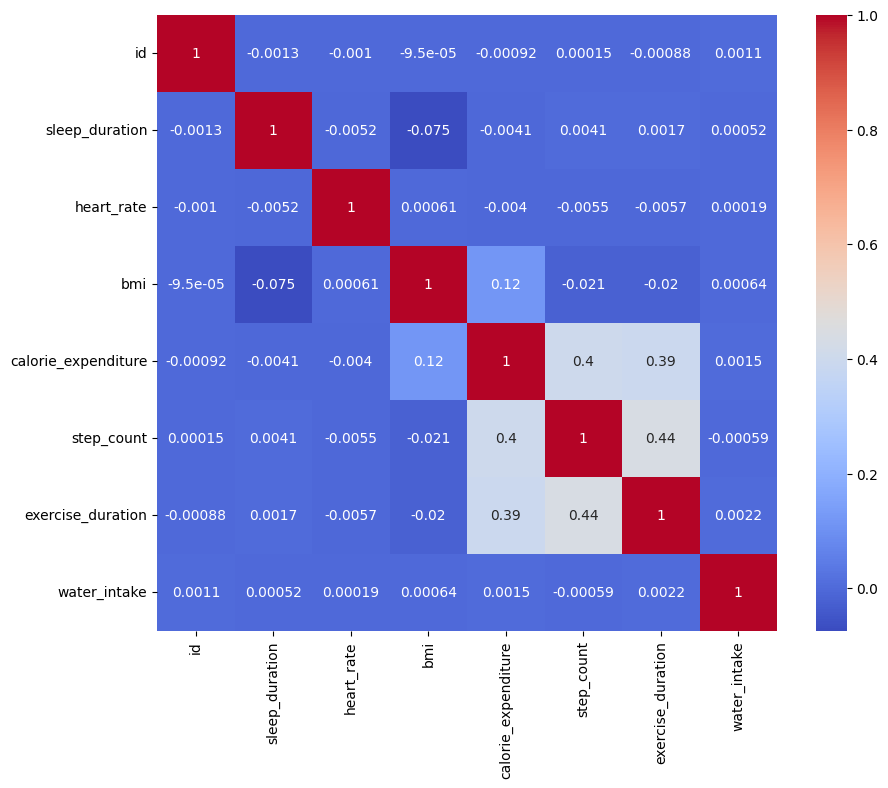

In [17]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [18]:
# categorical_count

cat_cols = train.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    display(
        train[col].value_counts().rename_axis(col).reset_index(name='Count')
    )

,health_condition,Count
0,at-risk,592561
1,unhealthy,57724
2,fit,39803


,diet_type,Count
0,veg,231432
1,balanced,226888
2,non-veg,224867


,stress_level,Count
0,medium,261819
1,high,177750
2,low,167708


,sleep_quality,Count
0,average,213948
1,poor,212166
2,good,205643


,physical_activity_level,Count
0,moderate,221041
1,sedentary,219784
2,active,212642


,smoking_alcohol,Count
0,yes,223730
1,no,219791
2,occasional,217985


,gender,Count
0,male,237756
1,female,224016
2,other,206943


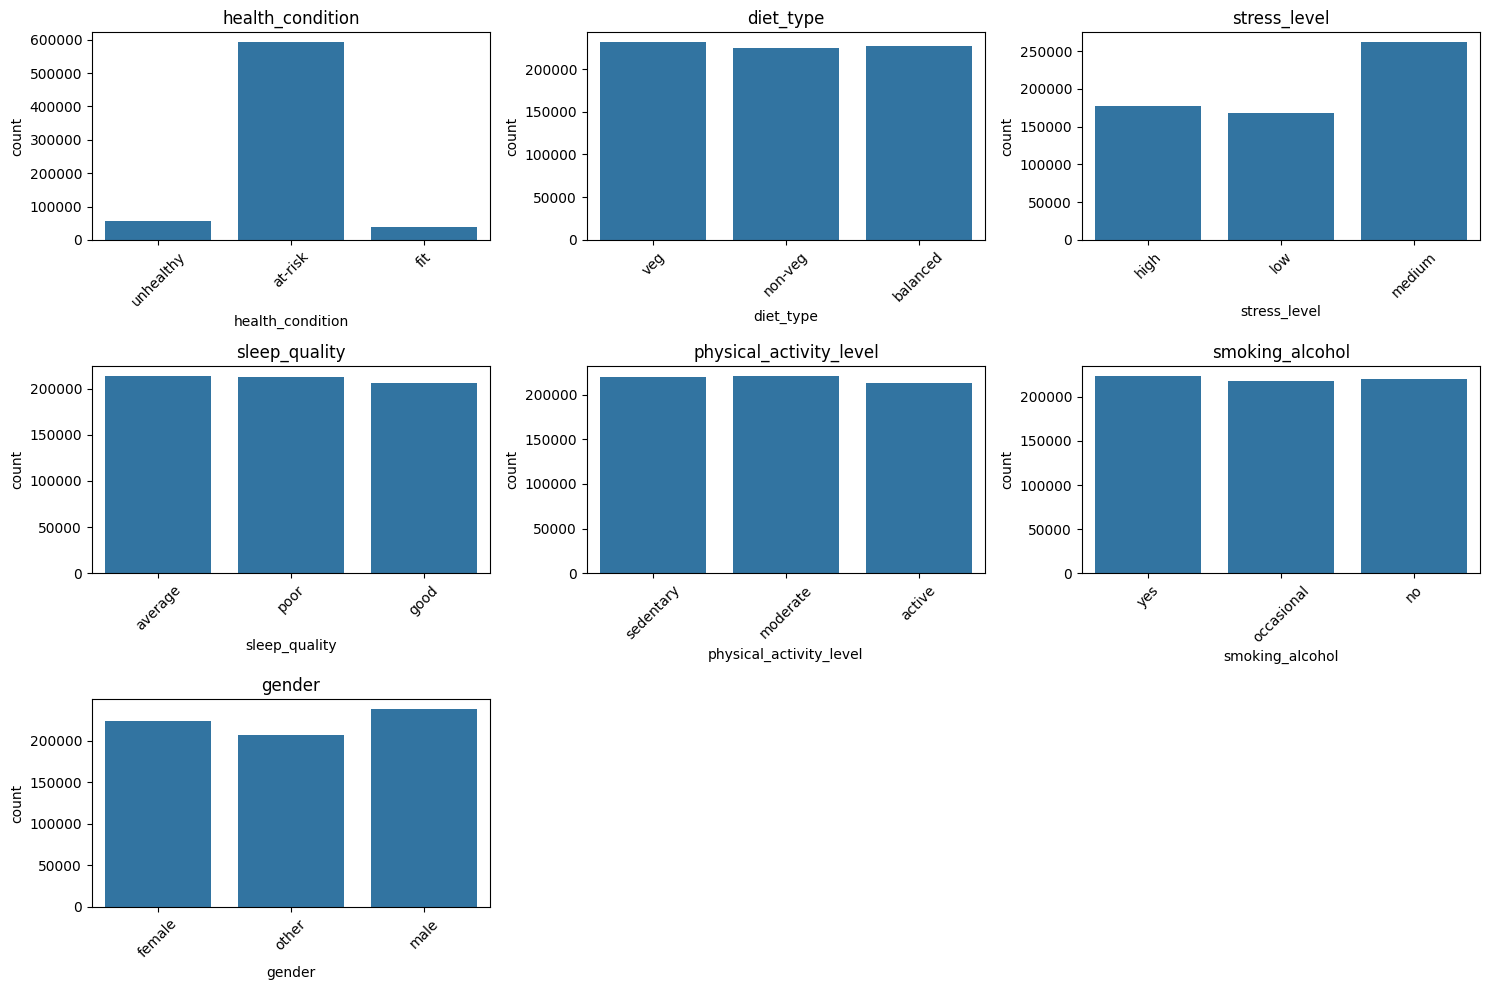

In [19]:
#Countplot distribution among categorical

cat_cols = train.select_dtypes(include=["object", "category"]).columns
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=train[col])
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

# Data Split

In [20]:
train.drop(["id"],axis = 1)

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [21]:
#Separate Features and Target and Split

X = train.drop("health_condition", axis=1)

y = train["health_condition"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
X_train

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
313415,313415,7.17,91.3,26.86,2635.0,1398.0,49.1,2.03,non-veg,medium,average,sedentary,yes,NaN
3515,3515,NaN,75.1,24.23,2382.0,13466.0,50.8,1.83,balanced,low,average,active,occasional,male
501194,501194,8.66,82.4,21.41,2314.0,9473.0,23.3,3.09,balanced,low,poor,sedentary,yes,female
303602,303602,NaN,74.5,22.59,2165.0,7052.0,21.6,1.92,veg,NaN,average,sedentary,occasional,male
117943,117943,8.83,68.2,22.01,2108.0,13521.0,52.9,2.35,non-veg,medium,average,active,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609022,609022,8.01,72.1,19.81,2231.0,3390.0,29.4,1.66,veg,high,poor,NaN,occasional,other
325552,325552,7.30,79.8,25.29,2358.0,3813.0,13.4,3.05,veg,high,average,sedentary,yes,male
393719,393719,8.13,80.1,23.41,NaN,10350.0,46.4,1.25,veg,medium,poor,moderate,occasional,male
619425,619425,5.87,69.3,21.27,2553.0,10398.0,57.6,NaN,balanced,medium,poor,active,no,female


# Outlier Handling

In [23]:
#Z-Score 

zscore_cols = ['sleep_duration'	,'heart_rate'	,'bmi']

mask = True

for col in zscore_cols:
    mean = X_train[col].mean()
    std = X_train[col].std()

    z_score = (X_train[col] - mean) / std

    mask = mask & (abs(z_score) <= 3)

X_train = X_train[mask]
y_train = y_train[mask]

In [24]:
X_train

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
313415,313415,7.17,91.3,26.86,2635.0,1398.0,49.1,2.03,non-veg,medium,average,sedentary,yes,NaN
501194,501194,8.66,82.4,21.41,2314.0,9473.0,23.3,3.09,balanced,low,poor,sedentary,yes,female
117943,117943,8.83,68.2,22.01,2108.0,13521.0,52.9,2.35,non-veg,medium,average,active,NaN,male
481608,481608,6.73,73.0,22.18,1334.0,1103.0,20.2,2.54,veg,medium,good,sedentary,yes,other
578601,578601,6.08,74.8,22.28,1828.0,8863.0,34.0,2.24,veg,low,average,moderate,occasional,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268583,268583,6.83,72.4,23.55,2734.0,6134.0,49.2,2.85,balanced,medium,poor,sedentary,yes,male
609022,609022,8.01,72.1,19.81,2231.0,3390.0,29.4,1.66,veg,high,poor,NaN,occasional,other
325552,325552,7.30,79.8,25.29,2358.0,3813.0,13.4,3.05,veg,high,average,sedentary,yes,male
393719,393719,8.13,80.1,23.41,NaN,10350.0,46.4,1.25,veg,medium,poor,moderate,occasional,male


In [25]:
# Make a copy
X_train = X_train.copy()

# IQR
iqr_cols = ["calorie_expenditure", "exercise_duration", "water_intake"]

for col in iqr_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = max(0, Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)

In [26]:
X_train

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
313415,313415,7.17,91.3,26.86,2635.0,1398.0,49.1,2.03,non-veg,medium,average,sedentary,yes,NaN
501194,501194,8.66,82.4,21.41,2314.0,9473.0,23.3,3.09,balanced,low,poor,sedentary,yes,female
117943,117943,8.83,68.2,22.01,2108.0,13521.0,52.9,2.35,non-veg,medium,average,active,NaN,male
481608,481608,6.73,73.0,22.18,1444.5,1103.0,20.2,2.54,veg,medium,good,sedentary,yes,other
578601,578601,6.08,74.8,22.28,1828.0,8863.0,34.0,2.24,veg,low,average,moderate,occasional,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268583,268583,6.83,72.4,23.55,2734.0,6134.0,49.2,2.85,balanced,medium,poor,sedentary,yes,male
609022,609022,8.01,72.1,19.81,2231.0,3390.0,29.4,1.66,veg,high,poor,NaN,occasional,other
325552,325552,7.30,79.8,25.29,2358.0,3813.0,13.4,3.05,veg,high,average,sedentary,yes,male
393719,393719,8.13,80.1,23.41,NaN,10350.0,46.4,1.25,veg,medium,poor,moderate,occasional,male


# Imputation and Scaling using Pipeline

In [27]:
#numeric columns
p1 = Pipeline(
    steps = [
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [28]:
# categories goes one after another via stricly following the order of the input
categories = [['low','medium','high'],['poor','average','good'],['sedentary','moderate','active'],['yes','occasional','no']]

In [29]:
# One-Hot Pipeline
p2 = Pipeline(
    steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
])

# Ordinal Pipeline
p3 = Pipeline(
    steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder()),
    ('scaler', MinMaxScaler())
])

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',p1,['sleep_duration'	,'heart_rate',	'bmi','calorie_expenditure',	'step_count',	'exercise_duration',	'water_intake']),
        ('pipeline_2',p2,['diet_type',"gender"]),
        ('pipeline_3',p3,['stress_level',	'sleep_quality',	'physical_activity_level',	'smoking_alcohol'])

    ],
    remainder='drop'
)
preprocessor

ColumnTransformer(transformers=[('pipeline_1',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['sleep_duration', 'heart_rate', 'bmi',
                                  'calorie_expenditure', 'step_count',
                                  'exercise_duration', 'water_intake']),
                                ('pipeline_2',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['diet_type', 'gender']),
                                ('pipeline_3',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder', OrdinalEncoder()),
                                                 ('scaler', MinMaxScaler())]),
                                 ['stress_level', 'sleep_quality',
                                  'physical_activity_level',
                                  'smoking_alcohol'])])

# LabelEncoder

In [31]:
le = LabelEncoder()

In [32]:
y_train = le.fit_transform(y_train)


In [33]:
y_test = le.transform(y_test)

# Build Model Pipeline

In [34]:

lr_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)
lr_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('pipeline_1',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sleep_duration',
                                                   'heart_rate', 'bmi',
                                                   'calorie_expenditure',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake']),
                                                 ('pipeline_2',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encod...
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['diet_type', 'gender']),
                                                 ('pipeline_3',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['stress_level',
                                                   'sleep_quality',
                                                   'physical_activity_level',
                                                   'smoking_alcohol'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# Model Train and predict



In [35]:
# Train
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluation

In [36]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred,average="weighted")

recall = recall_score(y_test, y_pred,average="weighted")

f1 = f1_score(y_test, y_pred,average="weighted")

print(accuracy)

print(precision)

print(recall)

print(f1)

print(classification_report(y_test, y_pred))

0.7397006187598719
0.8861814105067167
0.7397006187598719
0.7812630228001318
              precision    recall  f1-score   support

           0       0.97      0.72      0.83    118512
           1       0.25      0.91      0.40      7961
           2       0.43      0.82      0.57     11545

    accuracy                           0.74    138018
   macro avg       0.55      0.82      0.60    138018
weighted avg       0.89      0.74      0.78    138018



In [37]:
# Predict on unseen test data
test_pred_encoded = lr_model.predict(test)
test_pred_encoded

array([2, 0, 1, ..., 0, 0, 2])

In [38]:
test_pred = le.inverse_transform(test_pred_encoded)
test_pred


array(['unhealthy', 'at-risk', 'fit', ..., 'at-risk', 'at-risk',
       'unhealthy'], dtype=object)

# Submission

In [39]:
sample_submission.head(3)

,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk


In [40]:
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": test_pred
})

submission.to_csv("submission.csv", index=False)

In [41]:
submission.head(5)

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,fit
3,690091,at-risk
4,690092,unhealthy


In [42]:
import os
print(os.getcwd())

/kaggle/working


In [43]:
os.listdir("/kaggle/working")

['__notebook__.ipynb', 'submission.csv']